In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import os
import random

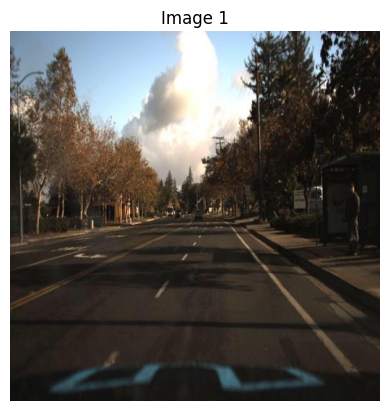

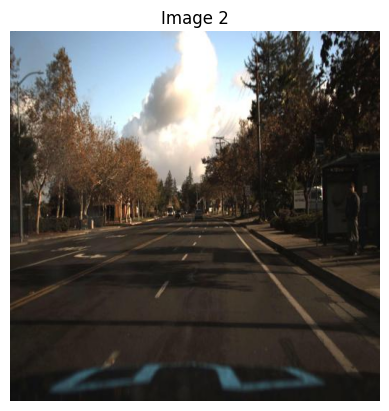

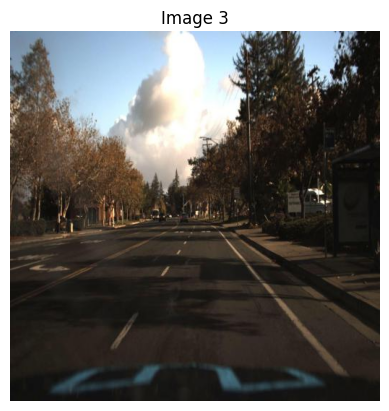

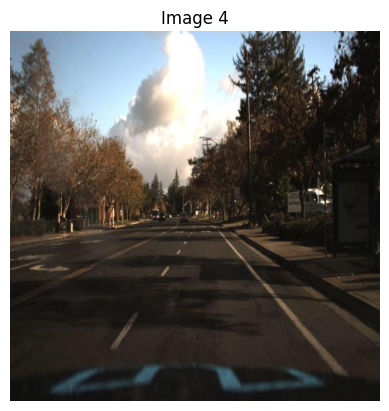

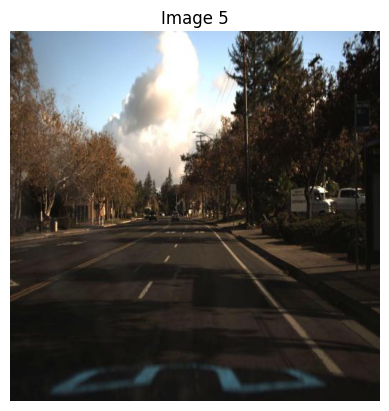

In [4]:
# Set the path to your dataset folder
DATASET_PATH = r'C:\Users\Dani\Desktop\Trabajo PID\BD\BD3\data\export'

# List all images in the dataset
image_files = [os.path.join(DATASET_PATH, file) for file in os.listdir(DATASET_PATH) if file.endswith('.jpg')]

# Display a few images to get a sense of the dataset
for i in range(5):
    img = Image.open(image_files[i])
    plt.figure()
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis('off')
    plt.show()

In [6]:
# Define actions (e.g., turn left, go straight, turn right)
ACTIONS = ['left', 'straight', 'right']
n_actions = len(ACTIONS)

# Initialize Q-table randomly
state_size = 1000  # Example state space size (modify based on your state representation)
Q_table = np.random.uniform(low=-1, high=1, size=(state_size, n_actions))

# Hyperparameters
alpha = 0.1      # Learning rate
gamma = 0.9      # Discount factor
epsilon = 0.1    # Exploration rate

def choose_action(state):
    # Epsilon-greedy strategy for choosing an action
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(ACTIONS)  # Explore
    else:
        return ACTIONS[np.argmax(Q_table[state])]  # Exploit

def update_q_table(state, action, reward, next_state):
    # Update Q-value using the Bellman equation
    action_index = ACTIONS.index(action)
    best_next_action = np.max(Q_table[next_state])
    Q_table[state, action_index] += alpha * (reward + gamma * best_next_action - Q_table[state, action_index])

In [7]:
# Example training loop (modify according to your dataset)
for episode in range(1000):  # Number of episodes
    state = np.random.randint(0, state_size)  # Randomly initialize state
    done = False

    while not done:
        # Choose an action
        action = choose_action(state)

        # Perform the action, get the next state and reward
        # Replace this with your logic (e.g., using image data for state updates)
        next_state = np.random.randint(0, state_size)  # Simulate state change
        reward = random.uniform(-1, 1)  # Simulate reward (change based on your criteria)

        # Update Q-table
        update_q_table(state, action, reward, next_state)

        # Move to the next state
        state = next_state

        # End condition (example)
        if random.uniform(0, 1) < 0.1:
            done = True

print("Training completed.")

Training completed.


In [8]:
import numpy as np
import random

# Define the environment
# For simplicity, let's assume we have 5 states and 3 possible actions (e.g., left, straight, right)
n_states = 5
n_actions = 3

# Initialize the Q-table with zeros
Q_table = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.1     # Learning rate
gamma = 0.9     # Discount factor
epsilon = 0.2   # Exploration rate
episodes = 1000  # Number of training episodes

# Define possible actions
ACTIONS = ['left', 'straight', 'right']

# Reward table (for the sake of this example, assume a predefined reward system)
# This is just an example; you should define rewards according to your problem.
REWARDS = np.random.uniform(-1, 1, (n_states, n_actions))  # Random rewards for each state-action pair

# Function to choose an action using the epsilon-greedy strategy
def choose_action(state):
    if np.random.uniform(0, 1) < epsilon:
        # Explore: choose a random action
        return np.random.choice(n_actions)
    else:
        # Exploit: choose the action with the highest Q-value for the current state
        return np.argmax(Q_table[state])

# Q-learning training loop
for episode in range(episodes):
    # Initialize the current state randomly
    current_state = np.random.randint(0, n_states)
    done = False
    
    while not done:
        # Choose an action
        action = choose_action(current_state)

        # Simulate the environment response
        # In a real-world scenario, you'll need a function to get the next state and reward
        # Here, it's randomly chosen for illustration purposes
        next_state = np.random.randint(0, n_states)
        reward = REWARDS[current_state, action]
        
        # Update the Q-value using the Q-learning update rule
        best_next_action = np.max(Q_table[next_state])
        Q_table[current_state, action] += alpha * (reward + gamma * best_next_action - Q_table[current_state, action])

        # Move to the next state
        current_state = next_state

        # Define an end condition (for this example, we'll randomly end the episode)
        if random.uniform(0, 1) < 0.1:
            done = True

# Display the learned Q-table
print("Learned Q-table:")
print(Q_table)

# Action interpretation based on the Q-table
def interpret_actions():
    for state in range(n_states):
        best_action_index = np.argmax(Q_table[state])
        print(f"Best action for state {state}: {ACTIONS[best_action_index]}")

interpret_actions()

Learned Q-table:
[[1.95466315 0.89110968 1.19663235]
 [1.09962523 0.52356213 0.74583986]
 [1.0509789  0.51506293 1.39156044]
 [1.82304212 1.66363868 1.60562458]
 [0.94814515 0.40989154 0.56732229]]
Best action for state 0: left
Best action for state 1: left
Best action for state 2: right
Best action for state 3: left
Best action for state 4: left
